# Numerical stability experiments

Testing how floating point math breaks down with memory limits.

## Float representations
Numbers are approximated in memory, so precision gets lost over time.

## Precision trade-offs
Lower precision saves memory and speeds things up, but gradients can easily underflow to zero or overflow to inf. This makes training unstable.

1. **Why can't computers represent all real numbers?**
Memory is finite, but real numbers are infinite. We have to approximate them.

2. **What does the mantissa do?**
It stores the actual digits of the fraction.

3. **What happens on overflow?**
The number gets too big for the exponent range and turns into `inf`.

4. **Why is float16 more unstable than float32?**
It has a way smaller exponent range and mantissa, so it overflows and loses precision way faster.

5. **Why don't ML models use float64?**
Float64 uses twice the memory and is slower on GPUs, which are optimized for float32 and below. The marginal precision gain just doesn't justify the cost for training large models.

6. **Why does lower precision improve speed/memory, and why is it risky for training?**
It cuts the memory footprint in half and runs faster on GPUs. But the gradients can underflow to zero, overflow to inf, or lose precision in small updates, which totally destabilizes training.

7. **Why is bfloat16 more stable than float16?**
It keeps the same exponent size as float32, so it doesn't overflow as easily. It just drops fractional precision instead.

8. **Why is lower precision safer at inference than training?**
Inference is just a forward pass with fixed weights. Training involves constantly accumulating tiny gradient updates, which get lost if the precision is too low.

In [14]:
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

os.makedirs('outputs', exist_ok=True)
np.random.seed(42)

In [15]:
a_32, b_32, c_32 = np.float32(1e8), np.float32(-1e8), np.float32(1)
print('float32 (a+b)+c:', (a_32 + b_32) + c_32)
print('float32 a+(b+c):', a_32 + (b_32 + c_32))

a_64, b_64, c_64 = np.float64(1e8), np.float64(-1e8), np.float64(1)
print('float64 (a+b)+c:', (a_64 + b_64) + c_64)
print('float64 a+(b+c):', a_64 + (b_64 + c_64))

a_py, b_py, c_py = 1e8, -1e8, 1
print('Python (a+b)+c:', (a_py + b_py) + c_py)
print('Python a+(b+c):', a_py + (b_py + c_py))

float32 (a+b)+c: 1.0
float32 a+(b+c): 0.0
float64 (a+b)+c: 1.0
float64 a+(b+c): 1.0
Python (a+b)+c: 1.0
Python a+(b+c): 1.0


9. **Why do the two expressions give different results?**
In `a + (b + c)`, `b + c` is `-1e8 + 1`. Since `float32` has a limited mantissa, the `1` gets dropped against the huge magnitude, leaving `-1e8`. Adding `1e8` makes it `0`. In `(a + b) + c`, the large numbers cancel first so the `1` survives. Float64 and Python (which natively uses float64) work correctly both ways because their mantissa has enough bits to hold `1e8 + 1` perfectly without dropping anything.

10. **Why is `0.1 + 0.2 == 0.3` false?**
Computers can't represent `0.1` and `0.2` perfectly in binary. The small rounding errors add up when you combine them.

11. **Identify overflow and underflow.**
`exp(1000)` is too big for float64 so it overflows to `inf`. `exp(-1000)` is too close to zero so it underflows to `0.0`.

12. **Why is the difference numerically unstable?**
Subtracting two huge numbers that are really close cancels out their leading bits, leaving just the noise. We can fix this by multiplying by the conjugate: `1 / (sqrt(x+1) + sqrt(x))`.

In [16]:
print('0.1 + 0.2 == 0.3:', 0.1 + 0.2 == 0.3)
print('Values stored:', 0.1 + 0.2, 0.3)

0.1 + 0.2 == 0.3: False
Values stored: 0.30000000000000004 0.3


In [17]:
val_overflow = np.exp(1000.0)
val_underflow = np.exp(-1000.0)

print(f'Positive exponential: {val_overflow}')
print(f'Negative exponential: {val_underflow}')

Positive exponential: inf
Negative exponential: 0.0


In [18]:
val_large = 1e8
res_diff = np.sqrt(val_large + 1) - np.sqrt(val_large)
res_stable = 1.0 / (np.sqrt(val_large + 1) + np.sqrt(val_large))

print(f'Unstable difference: {res_diff}')
print(f'Stable difference: {res_stable}')

Unstable difference: 5.000000055588316e-05
Stable difference: 4.9999999874999996e-05


## Softmax stability

In [19]:
def naive_softmax(x):
    return np.exp(x) / np.sum(np.exp(x))

x_input = np.array([1000.0, 1001.0, 1002.0])
print(f'Naive output: {naive_softmax(x_input)}')

Naive output: [nan nan nan]


13. **What goes wrong?**
The inputs are too big, so `exp()` overflows to `inf`. Then it tries to divide `inf` by `inf`, which gives `NaN`.

In [20]:
def stable_softmax(x):
    z = x - np.max(x)
    return np.exp(z) / np.sum(np.exp(z))

print(f'Stable output (NumPy): {stable_softmax(x_input)}')

try:
    import torch
    x_tensor = torch.tensor(x_input, dtype=torch.float64)
    print(f'Stable output (PyTorch): {torch.softmax(x_tensor, dim=0).numpy()}')
except ImportError:
    pass
except OSError as e:
    print(f'Skipped torch: {e}')

Stable output (NumPy): [0.09003057 0.24472847 0.66524096]
Stable output (PyTorch): [0.09003057 0.24472847 0.66524096]


14. **Compute softmax by hand**
For $x = [1, 2]$, $max = 2$, shifted $x = [-1, 0]$. Then: $e^{-1} \approx 0.368$, $e^0 = 1$, sum = $1.368$. Softmax = $[0.268, 0.732]$.

15. **Compare outputs**
Naive gives `NaN`, while stable shifting gives valid probabilities. PyTorch does the exact same shift trick internally.

16. **Why does subtracting max fix it?**
Softmax ratios don't change if you shift everything:
$$ \frac{e^{x_i-c}}{\sum e^{x_j-c}} = \frac{e^{x_i}}{\sum e^{x_j}} $$
Making the max `0` means the highest exponent is `1` and the rest are smaller, so nothing overflows.

## Precision on embeddings
We use the Russian–French interference corpus (Ortolang). Each speaker folder contains .wav recordings paired with _words.csv files giving word-level timestamps (semicolon-separated, no header, columns: word, start, end). We extract word segments by slicing the wav at the annotated boundaries, then pass each segment through facebook/wav2vec2-base and mean-pool the last hidden states over time to get one 768-dimensional embedding per word token.


In [21]:
import numpy as np
import json
import collections

data_64 = np.load('outputs/rep_float64.npy')
with open('outputs/labels.json', 'r') as f:
    labels = json.load(f)

speakers = set(l["speaker"] for l in labels)
words = set(l["word"] for l in labels)
print(f"Total vectors: {len(labels)}")
print(f"Speakers ({len(speakers)}): {sorted(speakers)}")
print(f"Unique words ({len(words)}): {sorted(words)[:20]}...")
word_counts = collections.Counter(l["word"] for l in labels)
print(f"Top 10 words: {word_counts.most_common(10)}")

Total vectors: 2310
Speakers (6): ['AB', 'AB2', 'AG', 'AN', 'AR', 'CB']
Unique words (28): ['cache', 'ceux', 'chie', 'dis', 'divan', 'fois', 'gabriel', 'garage', 'hier', "j'en", 'juxtaposer', 'l', 'la', 'louche', 'pas', 'pour', 'reste', 'roue', 'roule', 'roulé']...
Top 10 words: [('dis', 432), ('trois', 432), ('fois', 432), ('la', 144), ('rue', 74), ('cache', 72), ('roue', 71), ('sous', 38), ('juxtaposer', 36), ('pas', 36)]


Using min-max scaling for 8-bit. It's simple but definitely sensitive to outliers compared to clipping.

In [22]:
def quantize_8bit(x):
    x_min, x_max = x.min(), x.max()
    scale = (x_max - x_min) / 255.0
    x_q = np.round((x - x_min) / scale)
    return x_q.astype(np.uint8), scale, x_min

def dequantize_8bit(x_q, scale, x_min):
    return x_q.astype(np.float32) * scale + x_min

def compute_distances(data):
    norms = np.linalg.norm(data, axis=1, keepdims=True)
    normalized = data / (norms + 1e-10)
    return 1.0 - np.dot(normalized, normalized.T)

In [23]:
data_32 = data_64.astype(np.float32)
data_16 = data_64.astype(np.float16)
data_8q, scale_8, min_8 = quantize_8bit(data_64)

formats = {'float64': data_64, 'float32': data_32, 'float16': data_16, 'int8': data_8q}

import os
for name in formats:
    path = f'outputs/rep_{name}.npy'
    np.save(path, formats[name])
    print(f"{name}: {os.path.getsize(path)/1024:.1f} KB")

float64: 13860.1 KB
float32: 6930.1 KB
float16: 3465.1 KB
int8: 1732.6 KB


In [24]:
import time
dist_matrices = {}

for name, arr in formats.items():
    start = time.time()
    if name == 'int8':
        arr_calc = dequantize_8bit(arr, scale_8, min_8)
    else:
        arr_calc = arr
        
    dist_matrices[name] = compute_distances(arr_calc)
    print(f"{name} took {time.time() - start:.4f}s")

float64 took 0.2679s
float32 took 0.1161s
float16 took 22.6116s
int8 took 0.1045s


CPU `float16` can sometimes be slower because it has to be emulated in software.

In [25]:
ref = dist_matrices['float64']
intra_means = []
inter_means = []
ratios = []

for name, dists in dist_matrices.items():
    intra = []
    inter = []
    
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if labels[i]['word'] == labels[j]['word']:
                if labels[i]['speaker'] == labels[j]['speaker']:
                    intra.append(dists[i, j])
                else:
                    inter.append(dists[i, j])
                    
    i_mean = np.mean(intra)
    inter_mean = np.mean(inter)
    ratio = inter_mean / i_mean
    intra_means.append(i_mean)
    inter_means.append(inter_mean)
    ratios.append(ratio)
    
    diff = np.abs(ref - dists)
    print(f"{name} — intra: {i_mean:.4f}, inter: {inter_mean:.4f}, ratio: {ratio:.2f}, mean abs error: {diff.mean():.6f}")

float64 — intra: 0.3489, inter: 0.4113, ratio: 1.18, mean abs error: 0.000000
float32 — intra: 0.3489, inter: 0.4113, ratio: 1.18, mean abs error: 0.000000
float16 — intra: 0.3489, inter: 0.4114, ratio: 1.18, mean abs error: 0.000183
int8 — intra: 0.3493, inter: 0.4117, ratio: 1.18, mean abs error: 0.000870


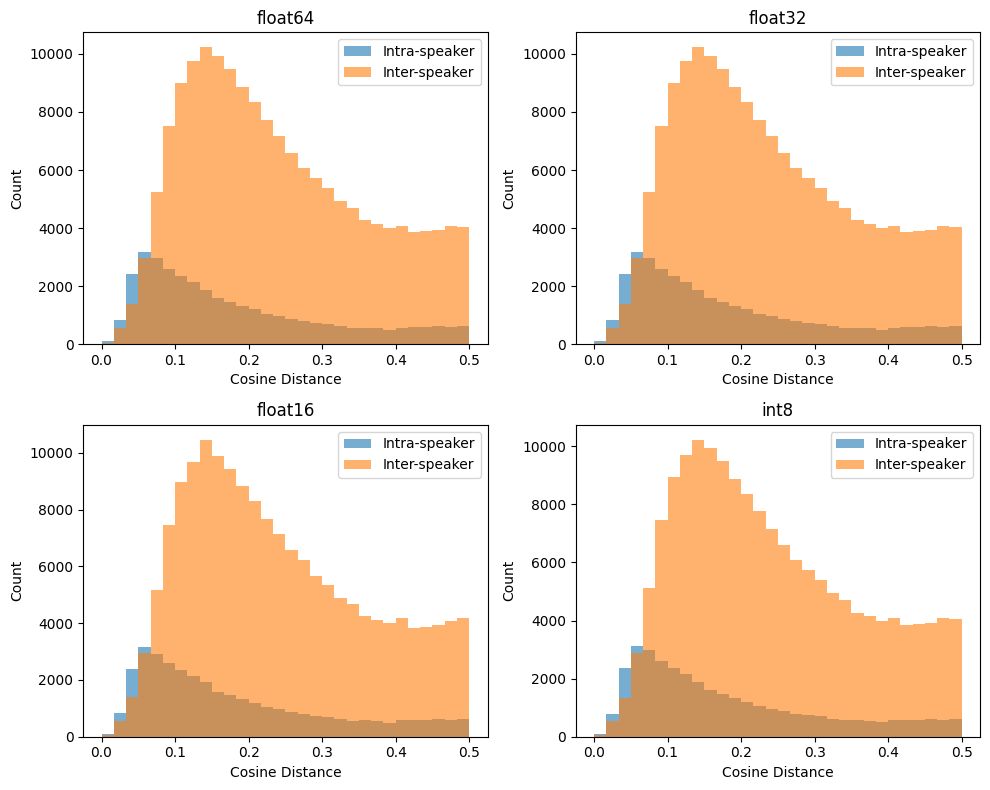

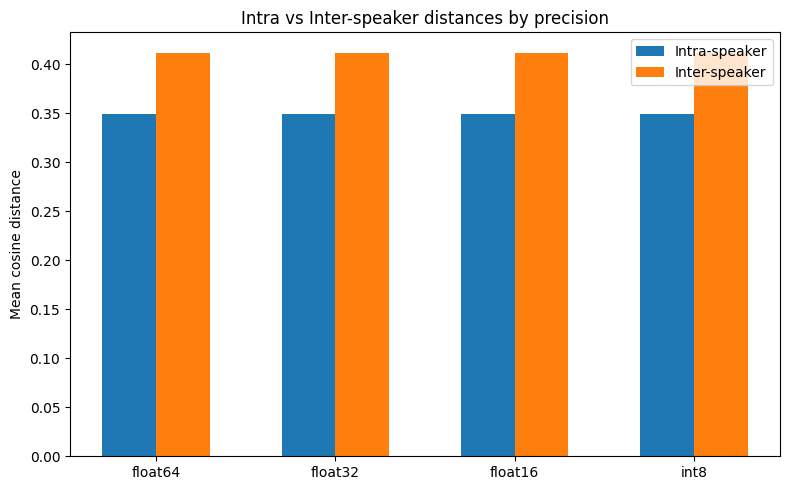

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (name, dists) in enumerate(dist_matrices.items()):
    ax = axes[idx]
    intra = []
    inter = []
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if labels[i]['word'] == labels[j]['word']:
                if labels[i]['speaker'] == labels[j]['speaker']:
                    intra.append(dists[i, j])
                else:
                    inter.append(dists[i, j])
                    
    ax.hist(intra, bins=30, range=(0.0, 0.5), alpha=0.6, label='Intra-speaker')
    ax.hist(inter, bins=30, range=(0.0, 0.5), alpha=0.6, label='Inter-speaker')
    ax.set_title(name)
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

x = np.arange(len(dist_matrices))
width = 0.3
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, intra_means, width, label='Intra-speaker')
ax.bar(x + width/2, inter_means, width, label='Inter-speaker')
ax.set_xticks(x)
ax.set_xticklabels(dist_matrices.keys())
ax.set_ylabel('Mean cosine distance')
ax.set_title('Intra vs Inter-speaker distances by precision')
ax.legend()
plt.tight_layout()
plt.show()